In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history (2).csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
scheme = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [4]:
print("NAV Columns:")
print(nav.columns)

print("\nAUM Columns:")
print(aum.columns)

print("\nSIP Columns:")
print(sip.columns)

print("\nCategory Columns:")
print(category.columns)

NAV Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')

AUM Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Category Columns:
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [5]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [7]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [8]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [9]:
print(nav.columns.tolist())
print(aum.columns.tolist())
print(sip.columns.tolist())

['amfi_code', 'date', 'nav']
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [10]:
nav['date'] = pd.to_datetime(nav['date'])


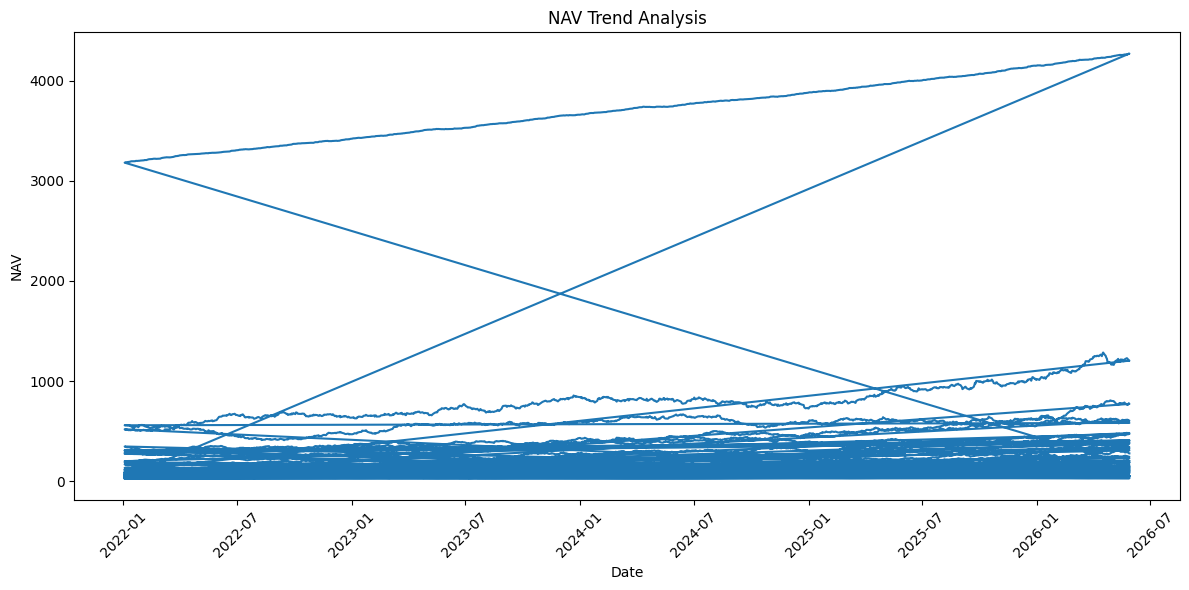

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(nav['date'], nav['nav'])

plt.title('NAV Trend Analysis')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [48]:
plt.savefig('../reports/nav_trend_analysis.png')

<Figure size 640x480 with 0 Axes>

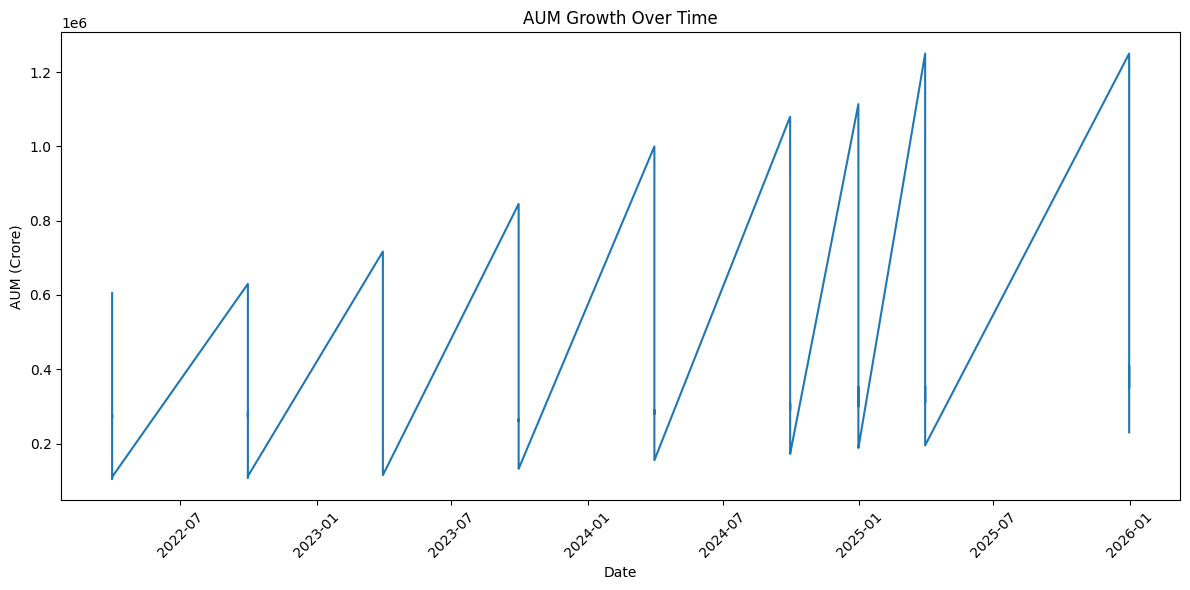

In [14]:
import matplotlib.pyplot as plt

# Convert date column
aum['date'] = pd.to_datetime(aum['date'])

plt.figure(figsize=(12,6))
plt.plot(aum['date'], aum['aum_crore'])

plt.title('AUM Growth Over Time')
plt.xlabel('Date')
plt.ylabel('AUM (Crore)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
plt.savefig('../reports/aum_growth_analysis.png')

<Figure size 640x480 with 0 Axes>

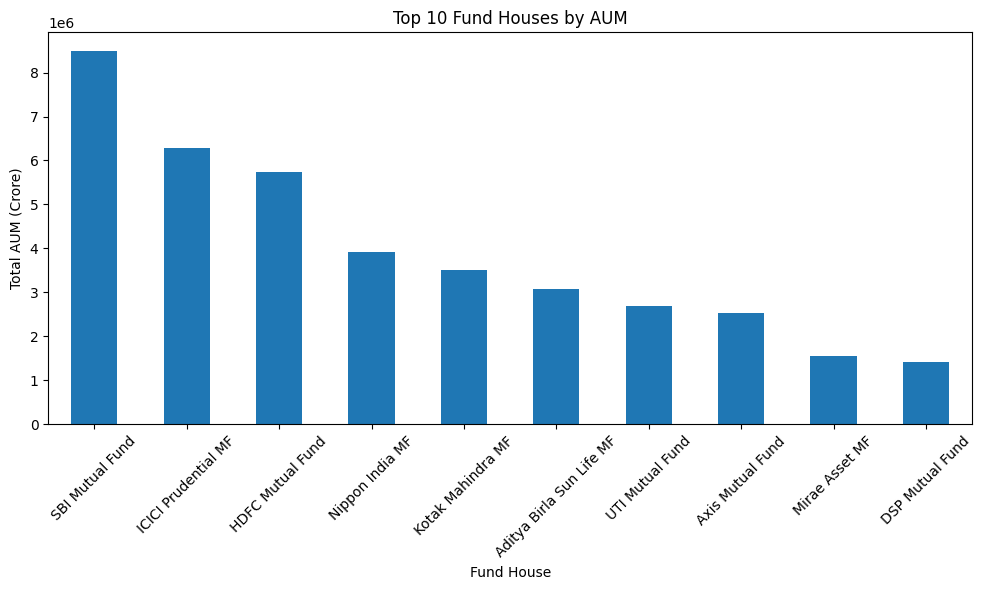

In [15]:
top_funds = aum.groupby('fund_house')['aum_crore'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_funds.plot(kind='bar')

plt.title('Top 10 Fund Houses by AUM')
plt.xlabel('Fund House')
plt.ylabel('Total AUM (Crore)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [50]:
plt.savefig('../reports/top_fund_houses_by_aum.png')

<Figure size 640x480 with 0 Axes>

In [16]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


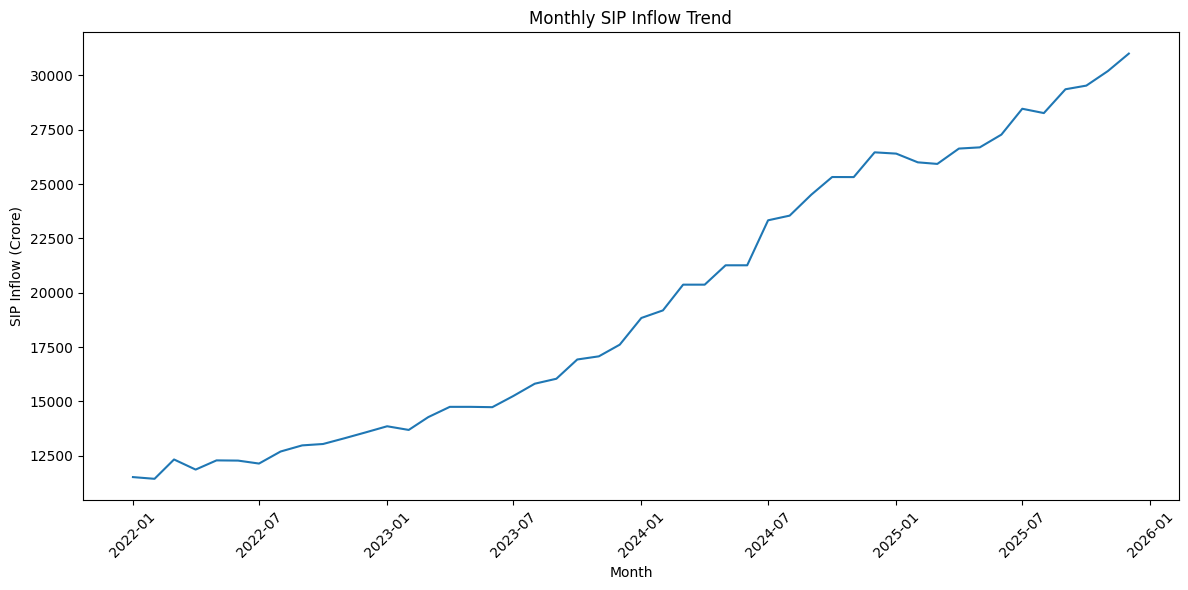

In [17]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,6))
plt.plot(sip['month'], sip['sip_inflow_crore'])

plt.title('Monthly SIP Inflow Trend')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
plt.savefig('../reports/sip_inflow_trend.png')

<Figure size 640x480 with 0 Axes>

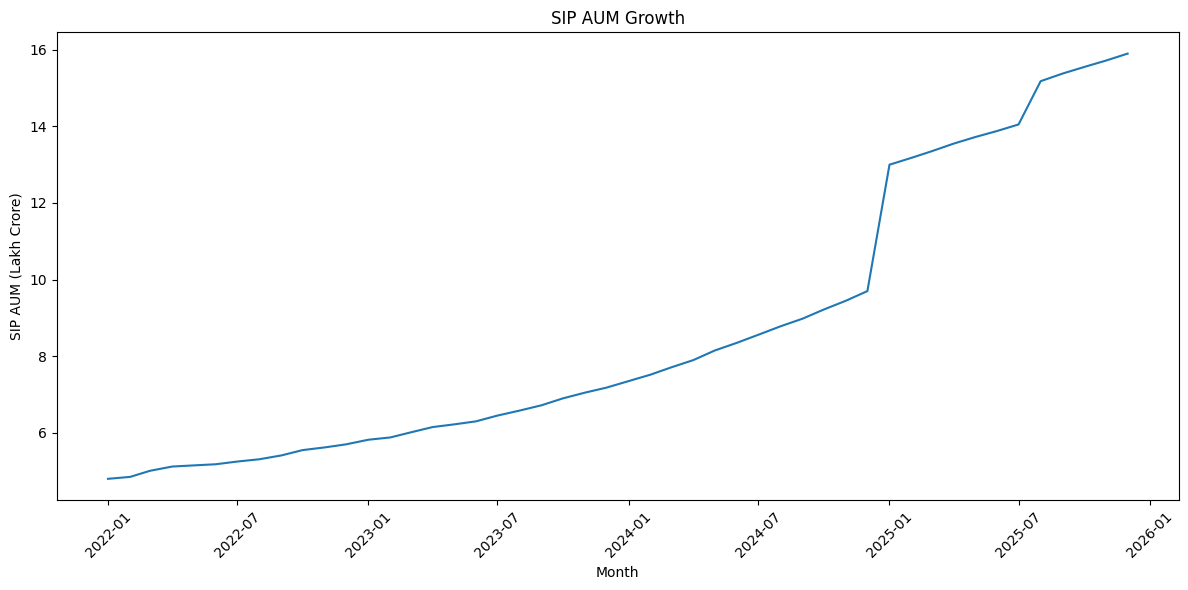

In [18]:
plt.figure(figsize=(12,6))
plt.plot(sip['month'], sip['sip_aum_lakh_crore'])

plt.title('SIP AUM Growth')
plt.xlabel('Month')
plt.ylabel('SIP AUM (Lakh Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
plt.savefig('../reports/sip_aum_growth.png')

<Figure size 640x480 with 0 Axes>

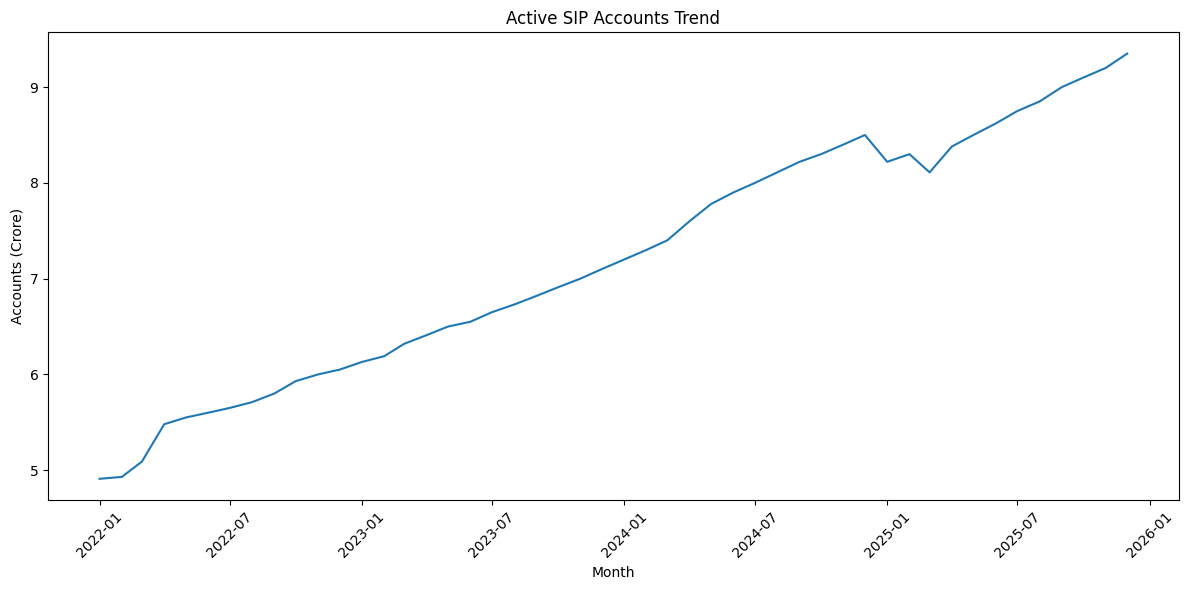

In [19]:
plt.figure(figsize=(12,6))
plt.plot(sip['month'], sip['active_sip_accounts_crore'])

plt.title('Active SIP Accounts Trend')
plt.xlabel('Month')
plt.ylabel('Accounts (Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
plt.savefig('../reports/active_sip_accounts_trend.png')

<Figure size 640x480 with 0 Axes>

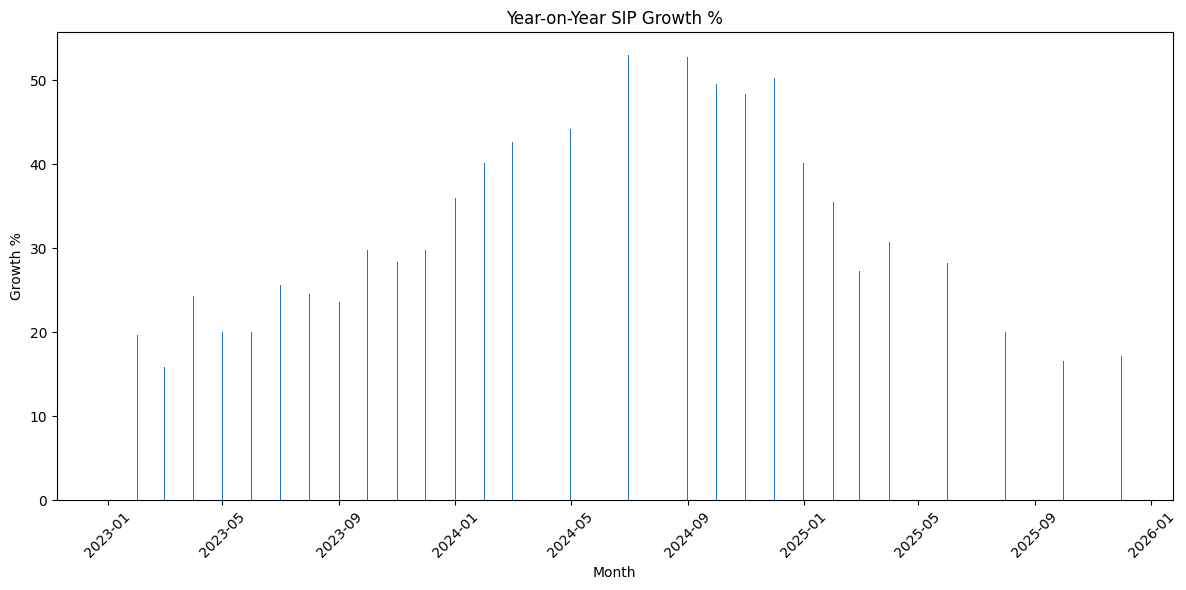

In [21]:
plt.figure(figsize=(12,6))
plt.bar(sip['month'], sip['yoy_growth_pct'])

plt.title('Year-on-Year SIP Growth %')
plt.xlabel('Month')
plt.ylabel('Growth %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
plt.savefig('../reports/yoy_sip_growth.png')

<Figure size 640x480 with 0 Axes>

In [24]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


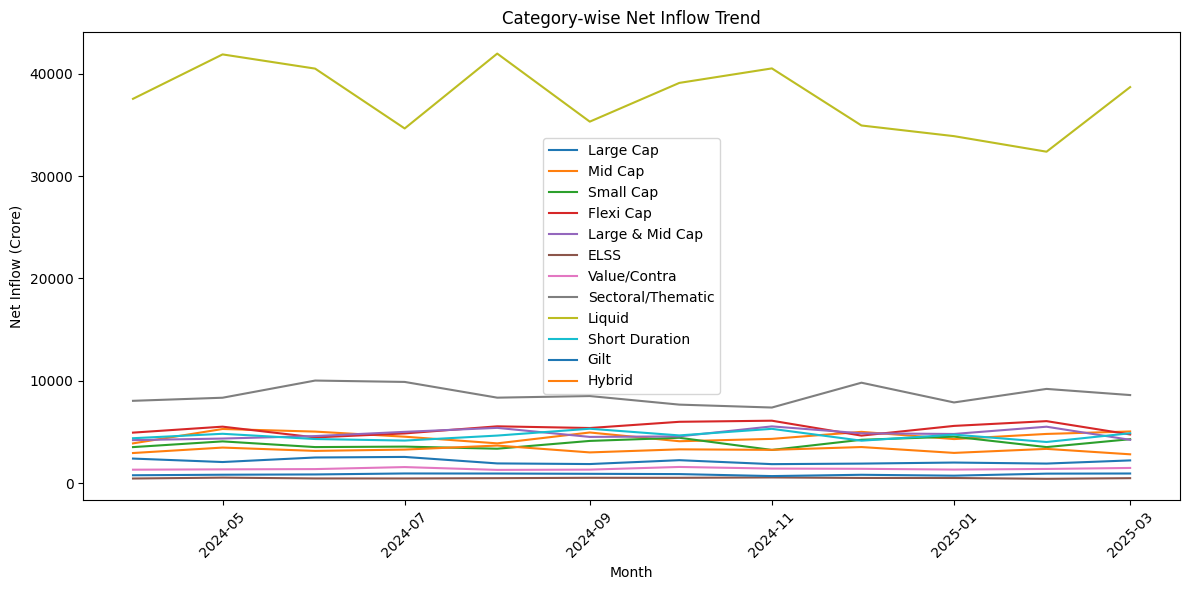

In [25]:
category['month'] = pd.to_datetime(category['month'])

plt.figure(figsize=(12,6))

for cat in category['category'].unique():
    temp = category[category['category'] == cat]
    plt.plot(temp['month'], temp['net_inflow_crore'], label=cat)

plt.title('Category-wise Net Inflow Trend')
plt.xlabel('Month')
plt.ylabel('Net Inflow (Crore)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [58]:
plt.savefig('../reports/category_inflow_trend.png')

<Figure size 640x480 with 0 Axes>

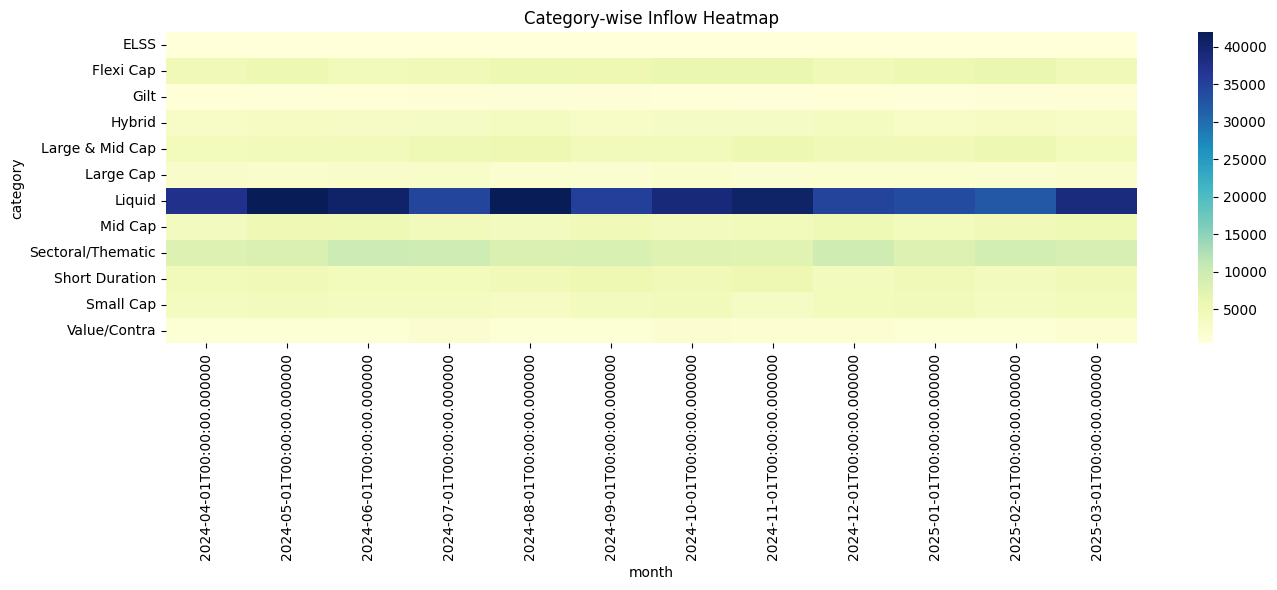

In [26]:
import seaborn as sns

heatmap_data = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap='YlGnBu')

plt.title('Category-wise Inflow Heatmap')
plt.tight_layout()
plt.show()

In [59]:
plt.savefig('../reports/category_inflow_heatmap.png')

<Figure size 640x480 with 0 Axes>

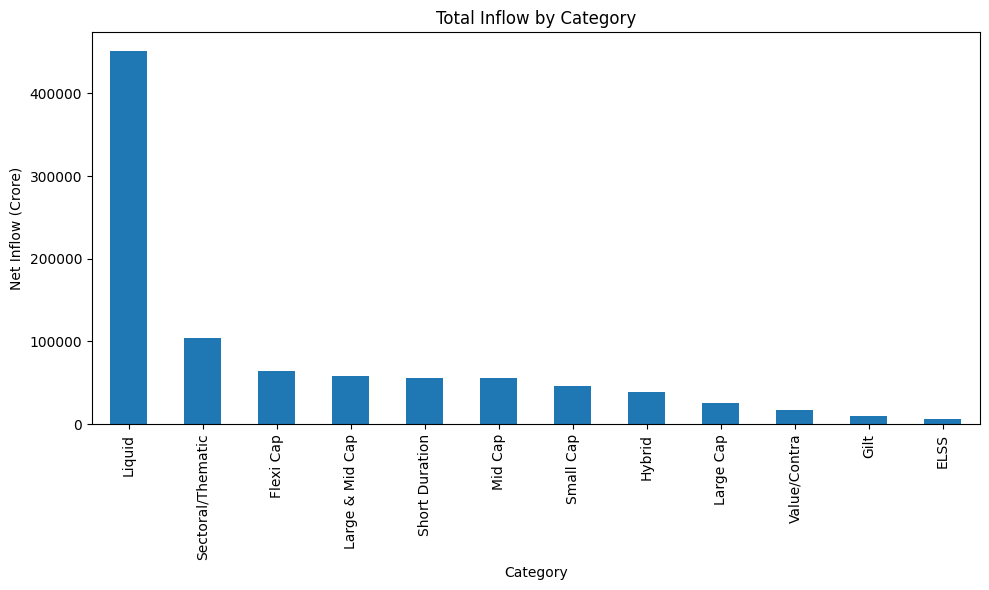

In [27]:
top_categories = category.groupby('category')['net_inflow_crore'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
top_categories.plot(kind='bar')

plt.title('Total Inflow by Category')
plt.xlabel('Category')
plt.ylabel('Net Inflow (Crore)')
plt.tight_layout()
plt.show()

In [60]:
plt.savefig('../reports/category_comparsion.png')

<Figure size 640x480 with 0 Axes>

In [28]:
print(folio.columns. tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


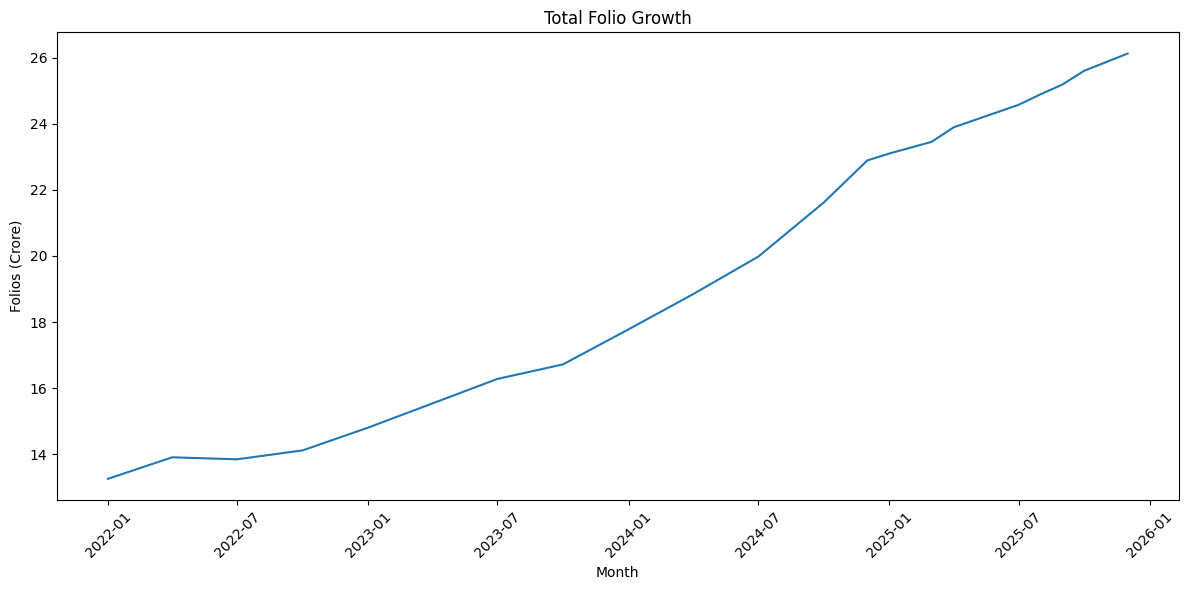

In [29]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))
plt.plot(folio['month'], folio['total_folios_crore'])

plt.title('Total Folio Growth')
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
plt.savefig('../reports/total_folio_growth.png')

<Figure size 640x480 with 0 Axes>

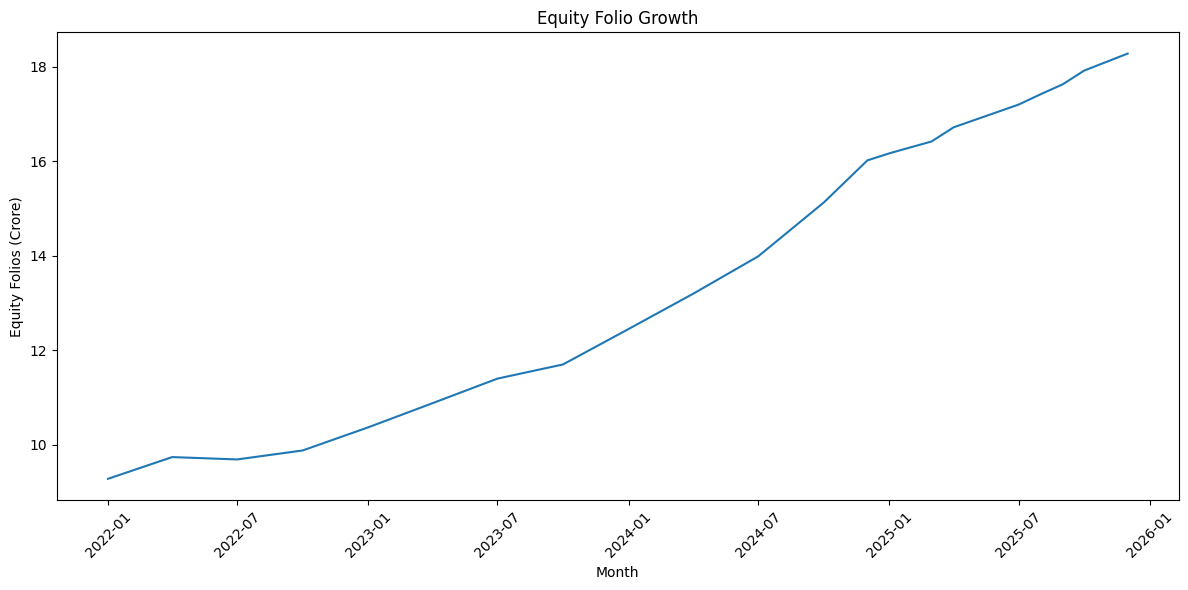

In [30]:
plt.figure(figsize=(12,6))
plt.plot(folio['month'], folio['equity_folios_crore'])

plt.title('Equity Folio Growth')
plt.xlabel('Month')
plt.ylabel('Equity Folios (Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
plt.savefig('../reports/equity_folio_growth.png')

<Figure size 640x480 with 0 Axes>

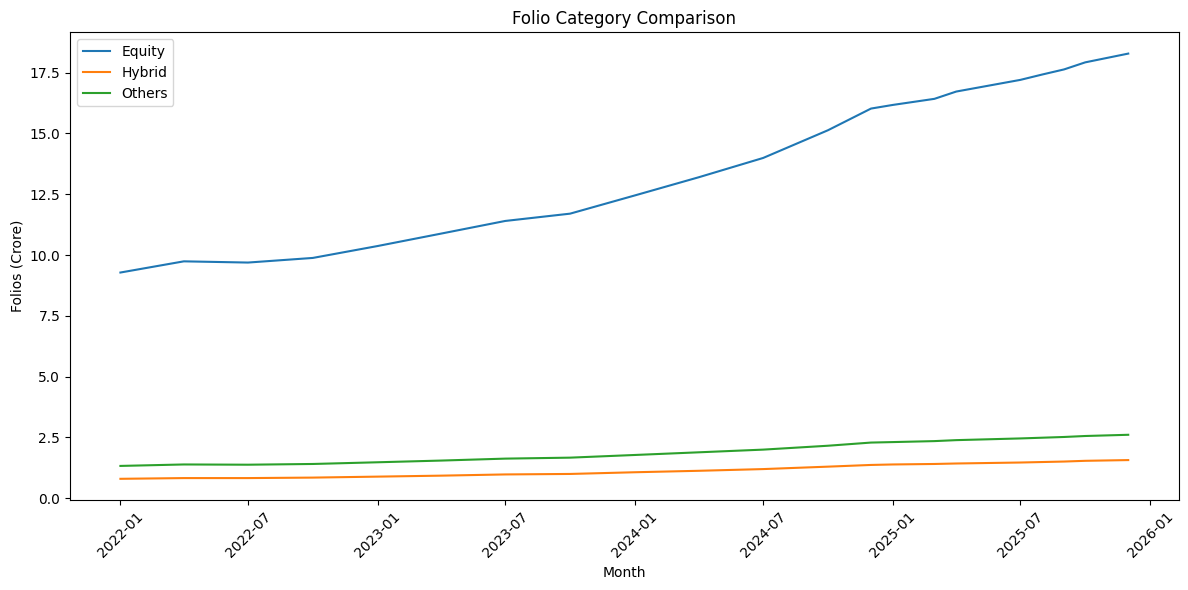

In [31]:
plt.figure(figsize=(12,6))

plt.plot(folio['month'], folio['equity_folios_crore'], label='Equity')
plt.plot(folio['month'], folio['hybrid_folios_crore'], label='Hybrid')
plt.plot(folio['month'], folio['others_folios_crore'], label='Others')

plt.title('Folio Category Comparison')
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
plt.savefig('../reports/folio_category_comparsion.png')

<Figure size 640x480 with 0 Axes>

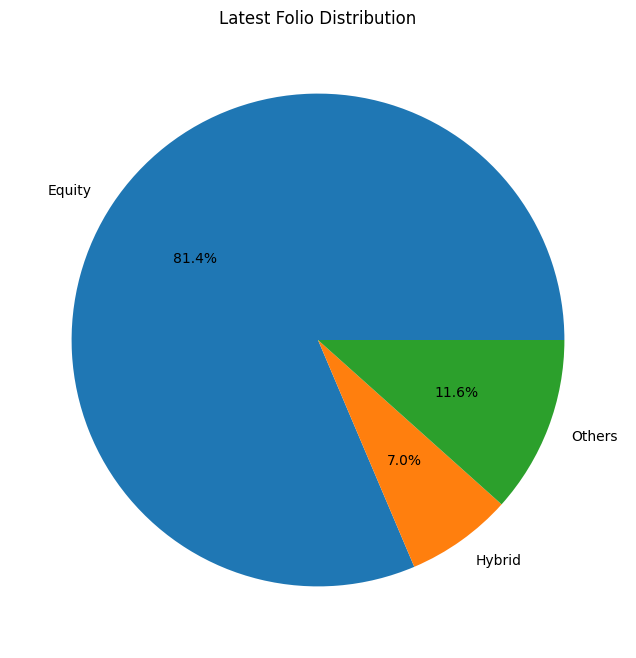

In [65]:
latest = folio.iloc[-1]

values = [
    latest['equity_folios_crore'],
    latest['hybrid_folios_crore'],
    latest['others_folios_crore']
]

labels = ['Equity', 'Hybrid', 'Others']

plt.figure(figsize=(8,8))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title('Latest Folio Distribution')
plt.show()

In [66]:
plt.savefig('../reports/folio_distribution.png')

<Figure size 640x480 with 0 Axes>

In [33]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


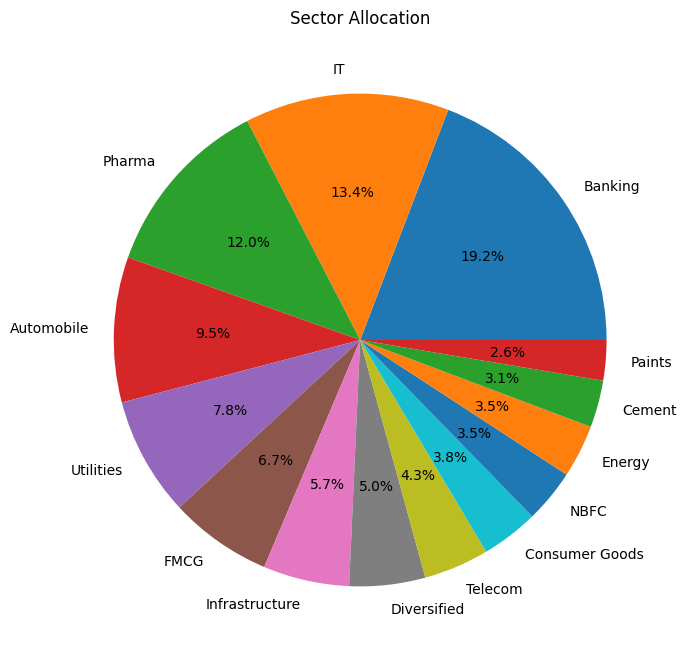

In [34]:
sector_data = holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))
plt.pie(sector_data, labels=sector_data.index, autopct='%1.1f%%')

plt.title('Sector Allocation')
plt.show()

In [67]:
plt.savefig('../reports/sector_allocation.png')

<Figure size 640x480 with 0 Axes>

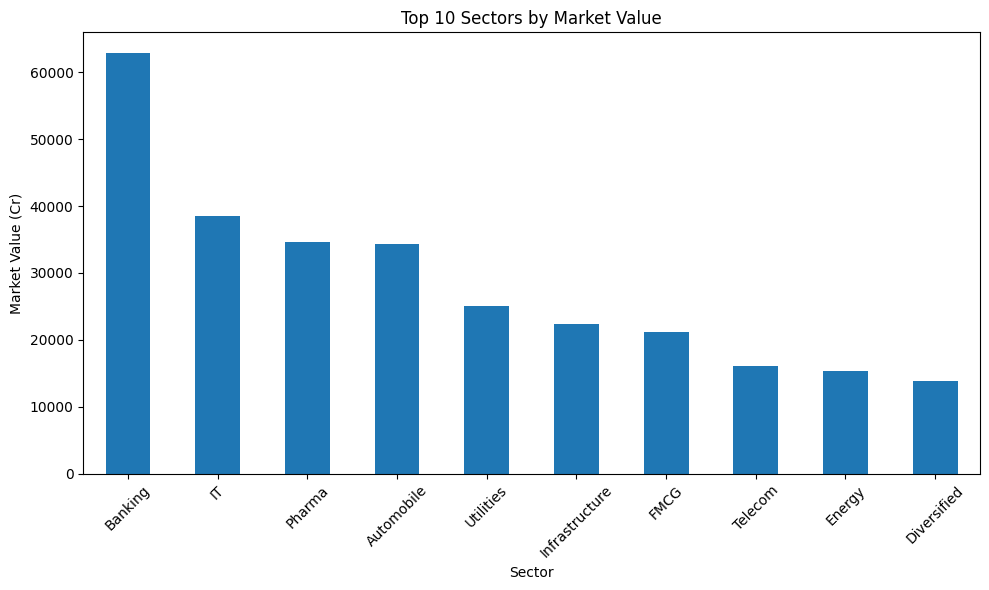

In [35]:
top_sectors = holdings.groupby('sector')['market_value_cr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_sectors.plot(kind='bar')

plt.title('Top 10 Sectors by Market Value')
plt.xlabel('Sector')
plt.ylabel('Market Value (Cr)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [68]:
plt.savefig('../reports/top_sectors_market_analysis.png')

<Figure size 640x480 with 0 Axes>

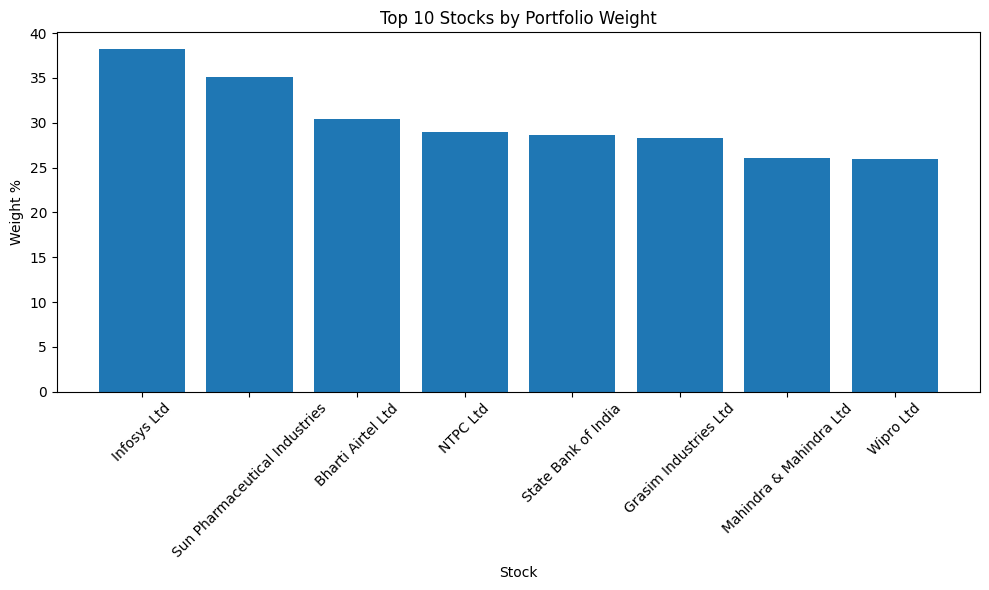

In [36]:
top_stocks = holdings.sort_values('weight_pct', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top_stocks['stock_name'], top_stocks['weight_pct'])

plt.title('Top 10 Stocks by Portfolio Weight')
plt.xlabel('Stock')
plt.ylabel('Weight %')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [69]:
plt.savefig('../reports/top_stocks_by_weight.png')

<Figure size 640x480 with 0 Axes>

In [37]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


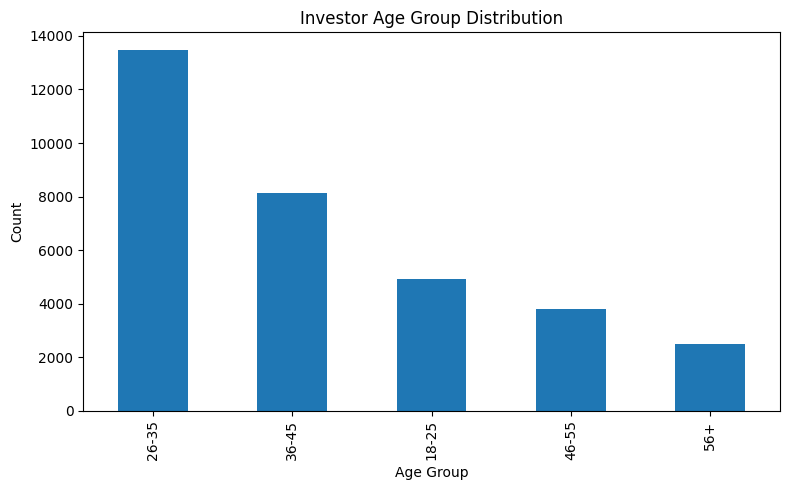

In [38]:
plt.figure(figsize=(8,5))
investor['age_group'].value_counts().plot(kind='bar')

plt.title('Investor Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [70]:
plt.savefig('../reports/age_group_distribution.png')

<Figure size 640x480 with 0 Axes>

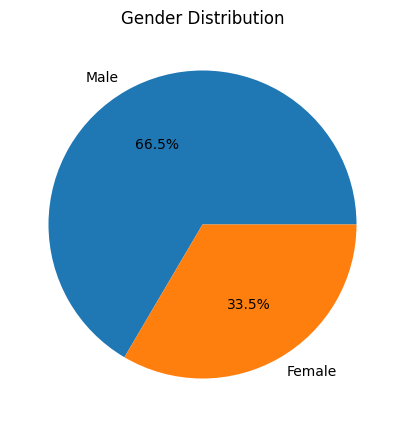

In [39]:
plt.figure(figsize=(8,5))
investor['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

In [72]:
plt.savefig('../reports/gender_distribution.png')

<Figure size 640x480 with 0 Axes>

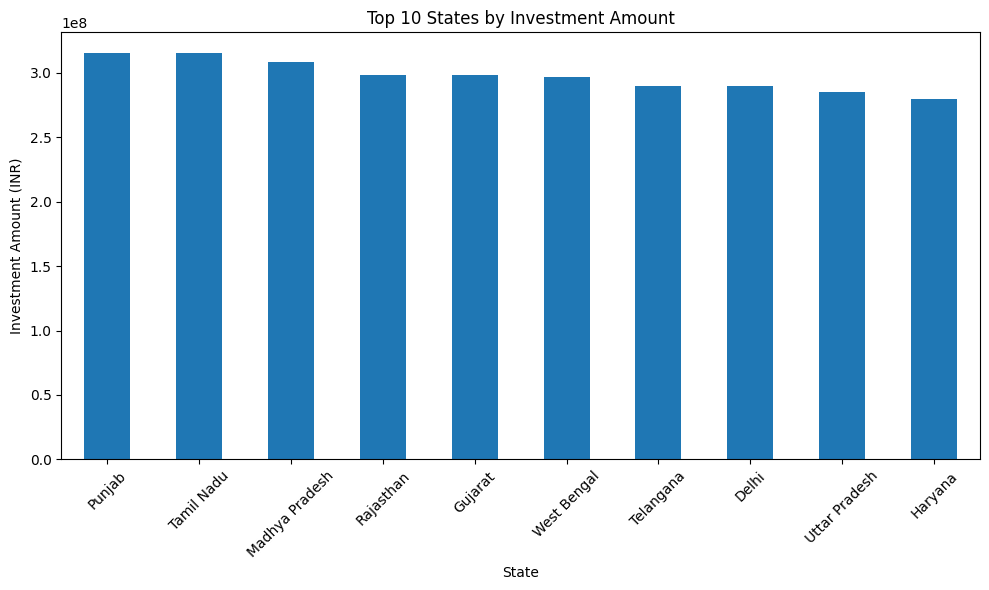

In [40]:
state_data = investor.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
state_data.plot(kind='bar')

plt.title('Top 10 States by Investment Amount')
plt.xlabel('State')
plt.ylabel('Investment Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
plt.savefig('../reports/state_wise_investments.png')

<Figure size 640x480 with 0 Axes>

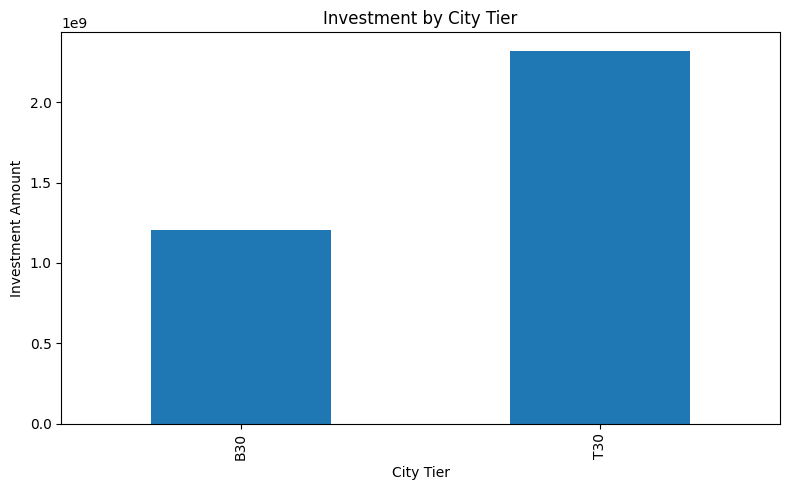

In [41]:
tier_data = investor.groupby('city_tier')['amount_inr'].sum()

plt.figure(figsize=(8,5))
tier_data.plot(kind='bar')

plt.title('Investment by City Tier')
plt.xlabel('City Tier')
plt.ylabel('Investment Amount')
plt.tight_layout()
plt.show()

In [75]:
plt.savefig('../reports/city_tier_analysis.png')

<Figure size 640x480 with 0 Axes>

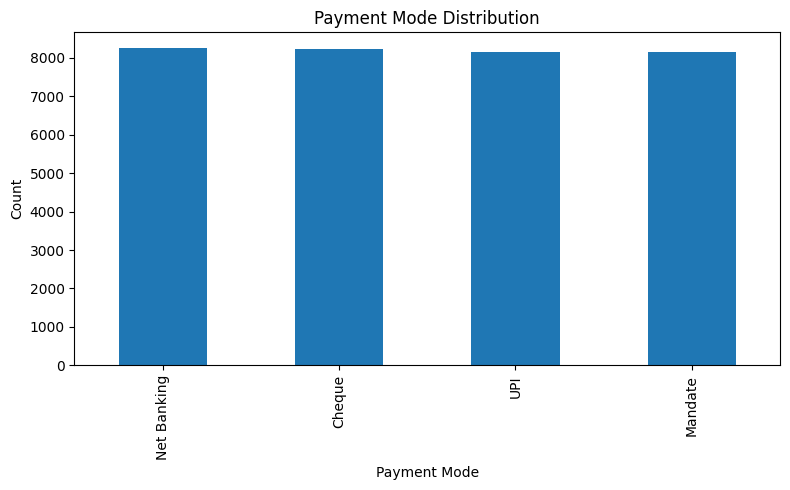

In [42]:
plt.figure(figsize=(8,5))
investor['payment_mode'].value_counts().plot(kind='bar')

plt.title('Payment Mode Distribution')
plt.xlabel('Payment Mode')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [76]:
plt.savefig('../reports/payment_mode_distribution.png')

<Figure size 640x480 with 0 Axes>

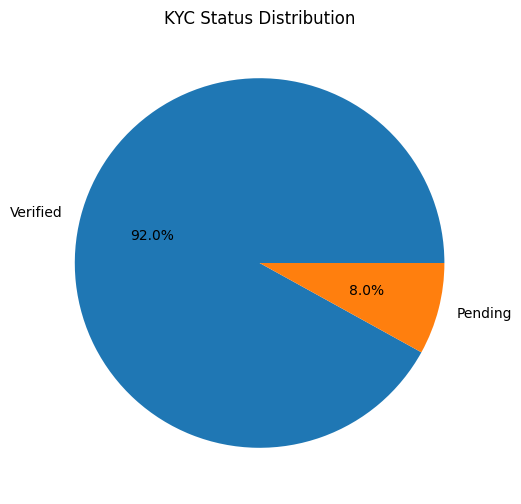

In [43]:
plt.figure(figsize=(6,6))
investor['kyc_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('KYC Status Distribution')
plt.ylabel('')
plt.show()

In [78]:
plt.savefig('../reports/kyc_status_distribution.png')

<Figure size 640x480 with 0 Axes>